# Support vector machine 

svm is a powerful achine learning algorithm used for classification and sumtime for regression

### Linear svm classifier 

In [49]:
from sklearn.datasets import load_iris

In [50]:
iris =  load_iris(as_frame= True)

In [51]:
X , y = iris.data.iloc[:, :2], iris.target
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int32

In [52]:
X.shape

(150, 2)

In [53]:
mask = y != 0
X = X[mask]
y = y[mask]


In [54]:
X.shape

(100, 2)

In [55]:
y

50     1
51     1
52     1
53     1
54     1
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 100, dtype: int32

In [56]:
y = y -1
y

50     0
51     0
52     0
53     0
54     0
      ..
145    1
146    1
147    1
148    1
149    1
Name: target, Length: 100, dtype: int32

In [57]:
from sklearn import svm

In [59]:
model   =  svm.SVC(kernel= 'linear')
model.fit (X, y)

SVC(kernel='linear')

In [63]:
x_min , x_max =   X.iloc[:, 0].min() - 1, X.iloc[:,0].max() + 1
y_min , y_max =   X.iloc[:, 1].min() - 1, X.iloc[:,1].max() + 1

In [64]:
import numpy as np


In [65]:
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     (y_min, y_max, 200))

In [70]:
Z =  model.predict(np.c_[xx.ravel(),yy.ravel() ])

c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [71]:
Z = Z.reshape(xx.shape)

In [73]:
import matplotlib.pyplot as plt

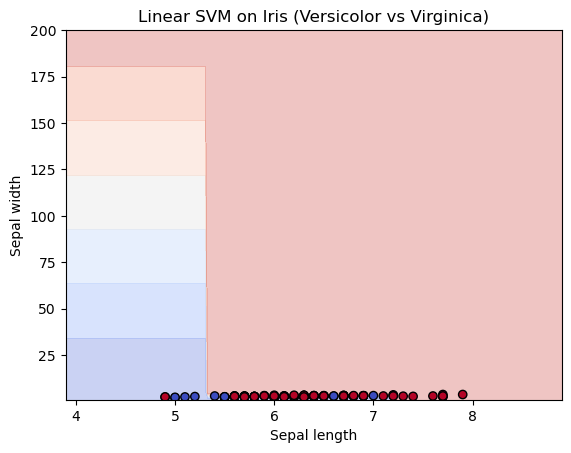

In [75]:
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Linear SVM on Iris (Versicolor vs Virginica)')
plt.show()

c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


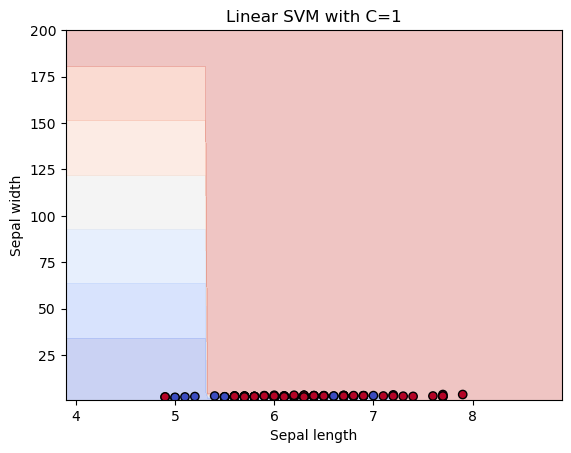

In [81]:
C_value = 1 # You can change this value to see effects

# Train SVM with linear kernel and given C
model = svm.SVC(kernel='linear', C=C_value)
model.fit(X, y)


x_min , x_max =   X.iloc[:, 0].min() - 1, X.iloc[:,0].max() + 1
y_min , y_max =   X.iloc[:, 1].min() - 1, X.iloc[:,1].max() + 1



# Predict on grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title(f'Linear SVM with C={C_value}')
plt.show()

c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


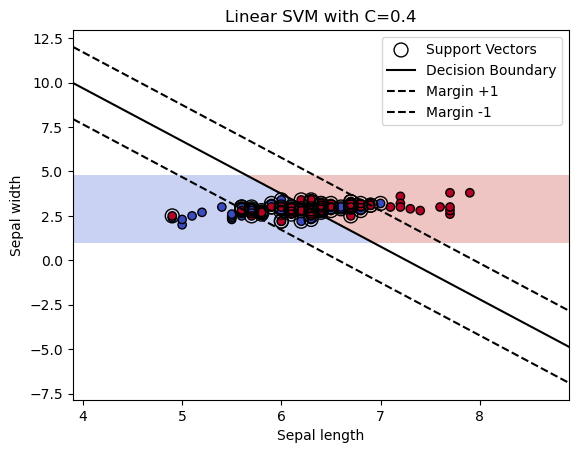

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets

# Load iris data as DataFrame
iris = datasets.load_iris(as_frame=True)
X = iris.data.iloc[:, :2]  # Sepal length and width
y = iris.target

# Filter classes 1 and 2 only
X = X[y != 0]
y = y[y != 0]
y = y - 1  # Labels 1,2 → 0,1

# Hyperparameter C
C_value = 0.4

# Train SVM with linear kernel and given C
model = svm.SVC(kernel='linear', C=C_value)
model.fit(X, y)

# Define plot limits
x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1

# Create meshgrid for plotting decision boundary
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict on grid points
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary and margin
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Plot training points
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')

# Plot support vectors
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='k', label='Support Vectors')

# Get the separating hyperplane
w = model.coef_[0]
b = model.intercept_[0]

# Create line space for plotting
x_plot = np.linspace(x_min, x_max, 200)

# Decision boundary formula: w0*x + w1*y + b = 0 => y = -(w0*x + b)/w1
decision_boundary = -(w[0] * x_plot + b) / w[1]

# Margins (distance ±1)
margin_positive = -(w[0] * x_plot + b - 1) / w[1]
margin_negative = -(w[0] * x_plot + b + 1) / w[1]

# Plot decision boundary and margins
plt.plot(x_plot, decision_boundary, 'k-', label='Decision Boundary')
plt.plot(x_plot, margin_positive, 'k--', label='Margin +1')
plt.plot(x_plot, margin_negative, 'k--', label='Margin -1')

plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title(f'Linear SVM with C={C_value}')
plt.legend()
plt.show()


# Using Kernal Poly 

Using polynomial function for classify the inputs

In [ ]:
model  =  svm.SVC(kernel = 'poly', C= C_value, degree= 3,  coef0= 1)
model.fit(X, y)

SVC(C=0.4, coef0=1, kernel='poly')

In [17]:
x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[: ,0].max() + 1
y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[: ,1].max() + 1


In [18]:
xx, yy = np.meshgrid( np.linspace(x_min, x_max, 300) ,
                     (y_min, y_max, 300) )

In [19]:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [20]:
Z = Z.reshape(xx.shape)

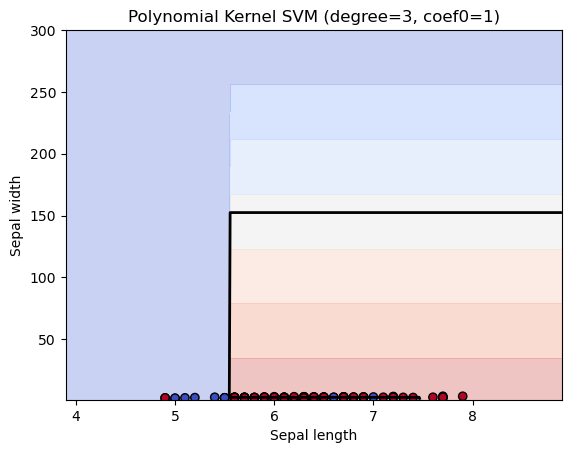

In [22]:
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Polynomial Kernel SVM (degree=3, coef0=1)')
plt.show()


# Radias Bias Function

The RBF kernel (also called Gaussian kernel) is a non-linear kernel used in SVM. It maps data into a higher-dimensional space where it can be linearly separated by a hyperplane.

In [24]:
model =  svm.SVC( kernel= 'rbf', C = 0.4, gamma= 0.4 )
model.fit(X, y)

SVC(C=0.4, gamma=0.4)

c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


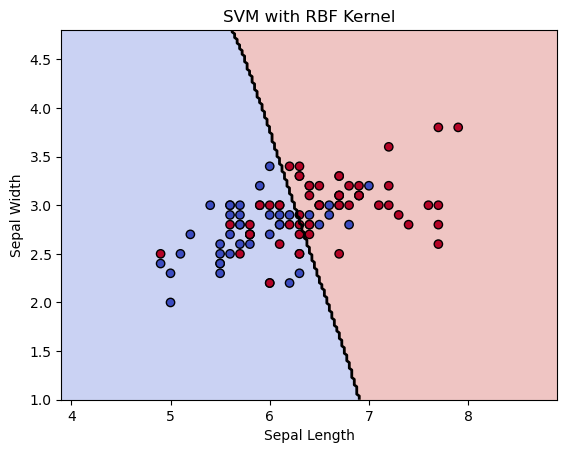

In [28]:
x_min, x_max = X.iloc[:, 0].min() - 1 , X.iloc[: , 0].max() + 1
y_min, y_max = X.iloc[:, 1].min() - 1 , X.iloc[: , 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
 
plt.contourf(xx, yy, Z, alpha =  0.3, cmap = plt.cm.coolwarm)
plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1],  c = y, cmap = plt.cm.coolwarm, edgecolors= 'k')
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("SVM with RBF Kernel")
plt.show()

# Support vector regression

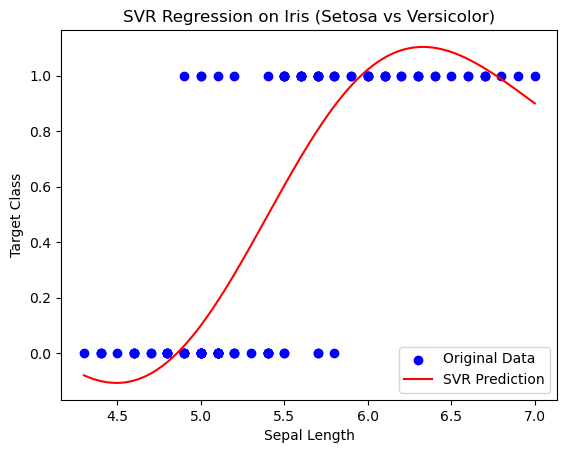

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.datasets import load_iris

# Load the dataset
iris = load_iris()
X = iris.data[:, [0]]  # Use only the first feature (sepal length)
y = iris.target

# Only use class 0 and 1 (Setosa and Versicolor) for regression
X = X[y != 2]
y = y[y != 2]

# Train SVR model
model = SVR(kernel='rbf', C=0.5, gamma=0.5, epsilon=0.1)
model.fit(X, y)

# Create test points for prediction
x_test = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_pred = model.predict(x_test)

# Plot the results
plt.scatter(X, y, color='blue', label='Original Data')
plt.plot(x_test, y_pred, color='red', label='SVR Prediction')
plt.xlabel('Sepal Length')
plt.ylabel('Target Class')
plt.title('SVR Regression on Iris (Setosa vs Versicolor)')
plt.legend()
plt.show()
